# Práctica 2 – Análisis estadístico de señales


**Universidad de Antioquia - Facultad de Ingeniería - Bioingeniería - Laboratorio Bioseñales y Sistemas**

- Mariana Paulina Vargas Velez
- Sofia Cedeño Vargas


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
DATA_DIR =Path(r"C:\Users\Lenovo\Desktop\Lab Bioseñales\biosenales_2026\practica_02\Parte2\ECGData")
DIAGNOSTICS_PATH = Path(r"C:\Users\Lenovo\Desktop\Lab Bioseñales\biosenales_2026\practica_02\Parte2\Diagnostics.xlsx")  # archivo de metadatos/etiquetas

assert os.path.exists(DIAGNOSTICS_PATH), "No se encontró Diagnostics.xlsx, ajuste la ruta"
assert os.path.isdir(DATA_DIR), "No se encontró la carpeta ECGData, ajuste la ruta"

AssertionError: No se encontró Diagnostics.xlsx, ajuste la ruta

## 1. Exploración y descripción de la base de datos

### 1.1 Carga de metadatos

In [ ]:
diag = pd.read_excel(DIAGNOSTICS_PATH)
diag.columns = [c.strip() for c in diag.columns]
print(f"Dimensiones de la tabla de metadatos: {diag.shape}")
diag.head()

Dimensiones de la tabla de metadatos: (10646, 16)


,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354


Los nombres exactos de columna pueden variar ligeramente entre versiones del archivo, por lo que se detectan de forma flexible (por palabra clave) en lugar de asumir un nombre fijo.

In [ ]:
def find_col(df, keywords):
    """Retorna la primera columna cuyo nombre (en minúsculas) contenga alguna de las keywords."""
    for col in df.columns:
        low = col.lower()
        if any(k in low for k in keywords):
            return col
    return None

col_filename = find_col(diag, ["filename", "file_name", "record"])
col_rhythm   = find_col(diag, ["rhythm"])
col_age      = find_col(diag, ["age"])
col_gender   = find_col(diag, ["gender", "sex"])

print("Columna de nombre de archivo :", col_filename)
print("Columna de ritmo/arritmia    :", col_rhythm)
print("Columna de edad              :", col_age)
print("Columna de género            :", col_gender)

Columna de nombre de archivo : FileName
Columna de ritmo/arritmia    : Rhythm
Columna de edad              : PatientAge
Columna de género            : Gender


### 1.2 Número total de registros y sujetos

In [ ]:
n_records = diag.shape[0]
print(f"Número total de registros: {n_records}")
print("En ChapmanECG cada registro corresponde a un único paciente, "
      "por lo que el número de sujetos es igual al número de registros.")

Número total de registros: 10646
En ChapmanECG cada registro corresponde a un único paciente, por lo que el número de sujetos es igual al número de registros.


### 1.3 Tipos de arritmias/clases y número de registros por grupo

In [ ]:
rhythm_counts = diag[col_rhythm].value_counts().sort_values(ascending=False)

tabla_ritmos = rhythm_counts.rename("N_registros").to_frame()
tabla_ritmos["Porcentaje (%)"] = (tabla_ritmos["N_registros"] / n_records * 100).round(2)
tabla_ritmos

,N_registros,Porcentaje (%)
Rhythm,,
SB,3889,36.53
SR,1826,17.15
AFIB,1780,16.72
ST,1568,14.73
SVT,587,5.51
AF,445,4.18
SA,399,3.75
AT,121,1.14
AVNRT,16,0.15


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6576\2213155585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rhythm_counts.index, y=rhythm_counts.values, palette="viridis")


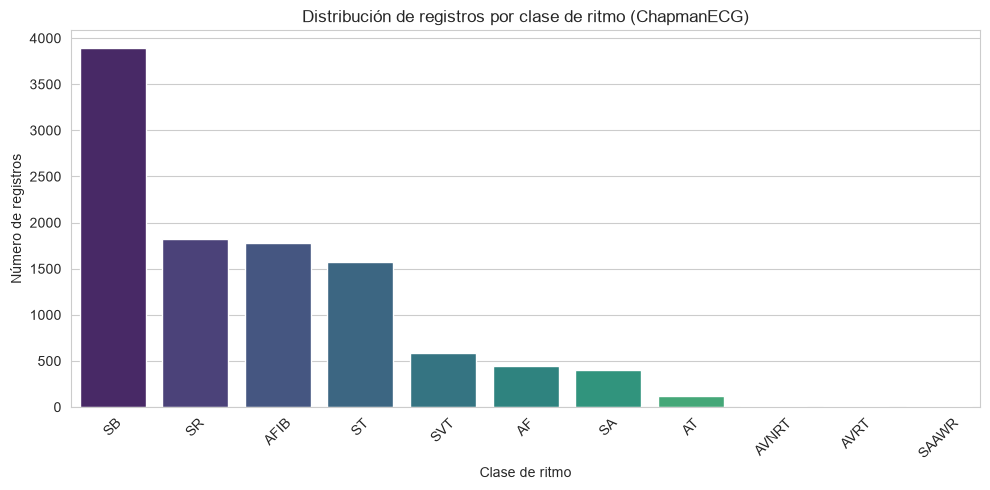

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=rhythm_counts.index, y=rhythm_counts.values, palette="viridis")
plt.ylabel("Número de registros")
plt.xlabel("Clase de ritmo")
plt.title("Distribución de registros por clase de ritmo (ChapmanECG)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Significado de los códigos de ritmo** (11 clases definidas por los expertos que etiquetaron la base de datos):

| Código | Ritmo |
|---|---|
| SB | Bradicardia sinusal |
| SR | Ritmo sinusal (normal) |
| AFIB | Fibrilación auricular |
| ST | Taquicardia sinusal |
| SVT | Taquicardia supraventricular |
| AF | Flutter (aleteo) auricular |
| SA | Arritmia sinusal (irregularidad sinusal) |
| AT | Taquicardia auricular |
| AVNRT | Taquicardia por reentrada nodal AV |
| AVRT | Taquicardia por reentrada AV |
| SAAWR | Ritmo sinusal con marcapasos auricular errante |

Se observa un marcado desbalance de clases: la bradicardia sinusal (SB) y el ritmo sinusal (SR) concentran la mayor parte de los registros, mientras que clases como AVNRT, AVRT y SAAWR tienen muy pocos casos (menos de 20 registros cada una). Este desbalance debe tenerse en cuenta al seleccionar y comparar grupos en el análisis estadístico.

### 1.4 Canales disponibles y derivaciones

In [ ]:
# Se toma un registro de ejemplo para inspeccionar la estructura de la señal
sample_name = diag[col_filename].iloc[0]
sample_name = sample_name if str(sample_name).endswith(".csv") else f"{sample_name}.csv"
sample_path = os.path.join(DATA_DIR, sample_name)

sample_signal = pd.read_csv(sample_path, header=None)
print("Forma de la señal de ejemplo (muestras x canales):", sample_signal.shape)

Forma de la señal de ejemplo (muestras x canales): (5001, 12)


In [ ]:
# Orden estándar de las 12 derivaciones en las que se entregan las señales de ChapmanECG
lead_names = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]
print(f"Número de canales/derivaciones: {sample_signal.shape[1]}")
print("Derivaciones:", lead_names)

Número de canales/derivaciones: 12
Derivaciones: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


### 1.5 Frecuencia de muestreo y duración de los registros

In [ ]:
fs = 500  # Hz — frecuencia de muestreo reportada para ChapmanECG
n_samples = sample_signal.shape[0]
duration_s = n_samples / fs

print(f"Frecuencia de muestreo : {fs} Hz")
print(f"Muestras por registro  : {n_samples}")
print(f"Duración por registro  : {duration_s:.1f} s")

Frecuencia de muestreo : 500 Hz
Muestras por registro  : 5001
Duración por registro  : 10.0 s


### 1.6 Resumen general

In [ ]:
resumen = pd.DataFrame({
    "Característica": ["Registros totales", "Sujetos", "Clases de ritmo",
                       "Canales/derivaciones", "Frecuencia de muestreo", "Duración por registro"],
    "Valor": [n_records, n_records, diag[col_rhythm].nunique(),
              sample_signal.shape[1], f"{fs} Hz", f"{duration_s:.1f} s"]
})
resumen

,Característica,Valor
0,Registros totales,10646
1,Sujetos,10646
2,Clases de ritmo,11
3,Canales/derivaciones,12
4,Frecuencia de muestreo,500 Hz
5,Duración por registro,10.0 s


### Demografía de los sujetos

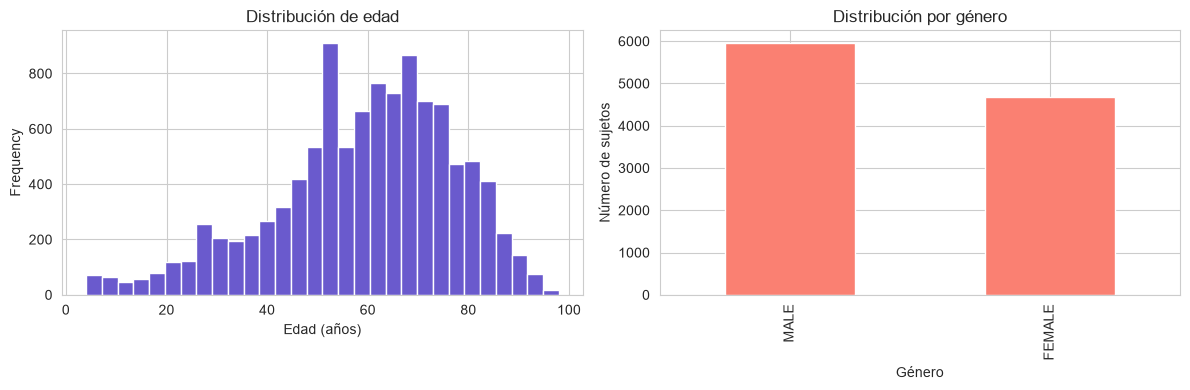

In [ ]:
if col_age is not None and col_gender is not None:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    diag[col_age].dropna().plot(kind="hist", bins=30, ax=axs[0], color="slateblue")
    axs[0].set_title("Distribución de edad")
    axs[0].set_xlabel("Edad (años)")

    diag[col_gender].value_counts().plot(kind="bar", ax=axs[1], color="salmon")
    axs[1].set_title("Distribución por género")
    axs[1].set_xlabel("Género")
    axs[1].set_ylabel("Número de sujetos")

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas de edad/género en el archivo de metadatos.")

## 2. Visualización y caracterización de las señales

Se seleccionan dos registros correspondientes a dos tipos de arritmia distintos para compararlos: **fibrilación auricular (AFIB)** y **bradicardia sinusal (SB)**. Ambas son relativamente frecuentes en la base de datos, lo que facilita encontrar ejemplos, y presentan características electrocardiográficas claramente diferenciables.

### 2.1 Breve consulta de las arritmias seleccionadas

**Fibrilación auricular (AFIB).** Es la arritmia sostenida más frecuente en la práctica clínica. Se origina por una activación eléctrica auricular desorganizada y caótica, proveniente de múltiples focos, que reemplaza la actividad sinusal normal. En el ECG se manifiesta por la ausencia de ondas P discretas (en su lugar aparecen ondulaciones irregulares de la línea de base, llamadas ondas f) y por una respuesta ventricular "irregularmente irregular", es decir, con intervalos R-R que varían de forma aleatoria de un latido a otro. Se asocia a un mayor riesgo de formación de trombos auriculares y eventos tromboembólicos (como el accidente cerebrovascular).

**Bradicardia sinusal (SB).** Es un ritmo que se origina en el nodo sinusal (por lo tanto conserva ondas P de morfología normal y una relación P-QRS 1:1, con intervalo PR normal), pero con una frecuencia cardiaca menor a 60 latidos por minuto. El ritmo es regular. Puede ser un hallazgo fisiológico (por ejemplo, en deportistas entrenados o durante el sueño) o estar asociado a disfunción del nodo sinusal, hipotiroidismo, hipotermia o al efecto de ciertos fármacos (betabloqueadores, digoxina, entre otros).

In [ ]:
def get_record(rhythm_code, index=0):
    """Obtiene la señal (n_muestras x 12) y los metadatos del registro `index`
    correspondiente a la clase de ritmo `rhythm_code`."""
    subset = diag[diag[col_rhythm] == rhythm_code].reset_index(drop=True)
    if subset.empty:
        raise ValueError(f"No se encontraron registros para la clase {rhythm_code}")
    fname = subset.loc[index, col_filename]
    fname = fname if str(fname).endswith(".csv") else f"{fname}.csv"
    path = os.path.join(DATA_DIR, fname)
    sig = pd.read_csv(path, header=0).values.astype(float)
    return sig, subset.loc[index]

rhythm_A, label_A = "AFIB", "Fibrilación auricular"
rhythm_B, label_B = "SB",   "Bradicardia sinusal"

sig_A, meta_A = get_record(rhythm_A, index=0)
sig_B, meta_B = get_record(rhythm_B, index=0)

print(f"Registro A ({label_A}):", meta_A[col_filename])
print(f"Registro B ({label_B}):", meta_B[col_filename])

Registro A (Fibrilación auricular): MUSE_20180113_171327_27000
Registro B (Bradicardia sinusal): MUSE_20180112_073319_29000


### 2.2 Visualización de la señal completa (10 s, derivación II)

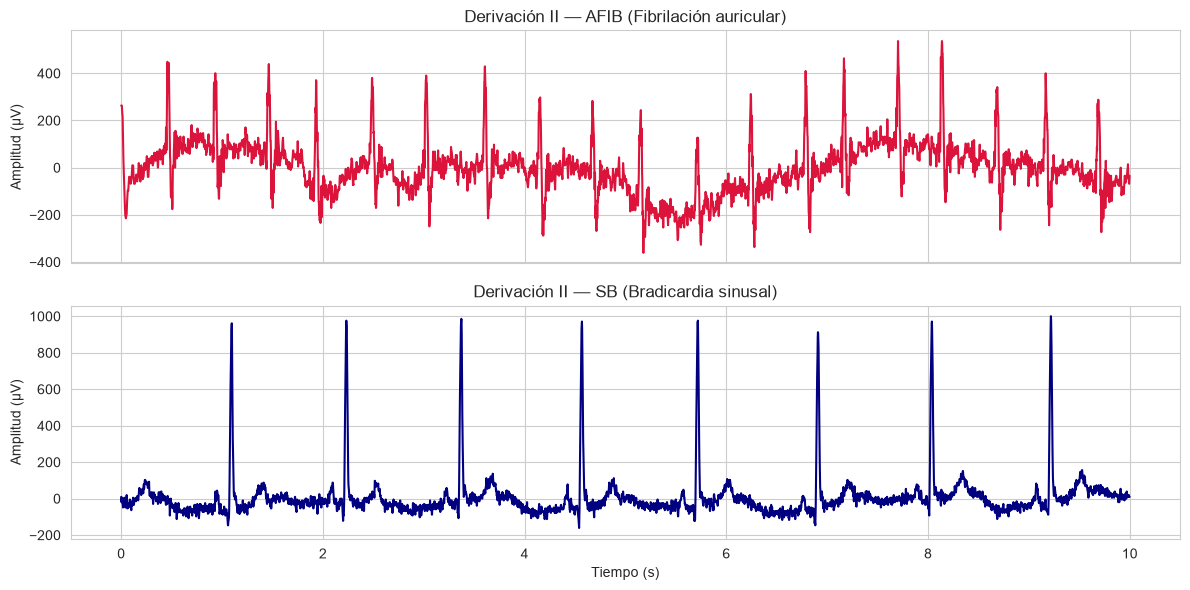

In [ ]:
lead_idx = lead_names.index("II")
t = np.arange(sig_A.shape[0]) / fs

zoom = (t >= 0) & (t <= 10)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t, sig_A[:, lead_idx], color="crimson")
axs[0].set_title(f"Derivación II — {rhythm_A} ({label_A})")
axs[0].set_ylabel("Amplitud (µV)")

axs[1].plot(t, sig_B[:, lead_idx], color="navy")
axs[1].set_title(f"Derivación II — {rhythm_B} ({label_B})")
axs[1].set_ylabel("Amplitud (µV)")
axs[1].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()

### 2.3 Acercamiento (0-3 s) para observar la morfología del latido

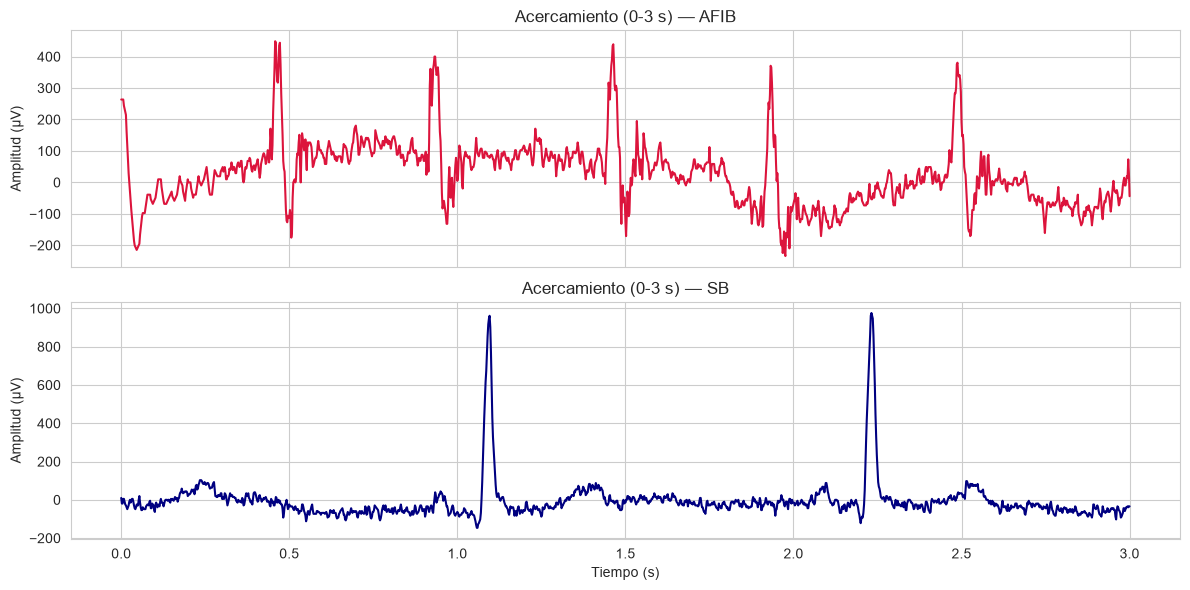

In [ ]:
zoom = (t >= 0) & (t <= 3)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t[zoom], sig_A[zoom, lead_idx], color="crimson")
axs[0].set_title(f"Acercamiento (0-3 s) — {rhythm_A}")
axs[0].set_ylabel("Amplitud (µV)")

axs[1].plot(t[zoom], sig_B[zoom, lead_idx], color="navy")
axs[1].set_title(f"Acercamiento (0-3 s) — {rhythm_B}")
axs[1].set_ylabel("Amplitud (µV)")
axs[1].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()

### 2.4 Detección de picos R, frecuencia cardiaca y regularidad

In [ ]:
def detect_r_peaks(signal, fs, min_rr_s=0.3):
    """Detección simple de picos R por umbral adaptativo."""

    # Convertir la señal a un arreglo numérico
    signal = np.asarray(signal)

    # Reemplazar comas decimales por puntos
    if signal.dtype.kind in {"U", "S", "O"}:
        signal = np.array(
            [str(val).replace(",", ".") for val in signal],
            dtype=float
        )
    else:
        signal = signal.astype(float)

    # Verificar que no haya valores inválidos
    if not np.all(np.isfinite(signal)):
        raise ValueError("La señal contiene valores NaN o infinitos.")

    # Umbral adaptativo
    height = np.mean(signal) + 2 * np.std(signal)

    # Detección de picos R
    peaks, _ = find_peaks(
        signal,
        height=height,
        distance=int(min_rr_s * fs)
    )

    return peaks

peaks_A = detect_r_peaks(sig_A[:, lead_idx], fs)
peaks_B = detect_r_peaks(sig_B[:, lead_idx], fs)

rr_A = np.diff(peaks_A) / fs   # intervalos R-R en segundos
rr_B = np.diff(peaks_B) / fs

hr_A = 60 / rr_A                # frecuencia cardiaca instantánea (lpm)
hr_B = 60 / rr_B

print(f"{rhythm_A} ({label_A}):")
print(f"  Picos R detectados : {len(peaks_A)}")
print(f"  FC promedio        : {hr_A.mean():.1f} lpm")
print(f"  Desv. estándar RR  : {rr_A.std()*1000:.1f} ms  (mayor valor = más irregular)")
print()
print(f"{rhythm_B} ({label_B}):")
print(f"  Picos R detectados : {len(peaks_B)}")
print(f"  FC promedio        : {hr_B.mean():.1f} lpm")
print(f"  Desv. estándar RR  : {rr_B.std()*1000:.1f} ms  (mayor valor = más irregular)")

AFIB (Fibrilación auricular):
  Picos R detectados : 18
  FC promedio        : 115.5 lpm
  Desv. estándar RR  : 145.2 ms  (mayor valor = más irregular)

SB (Bradicardia sinusal):
  Picos R detectados : 8
  FC promedio        : 51.7 lpm
  Desv. estándar RR  : 25.6 ms  (mayor valor = más irregular)


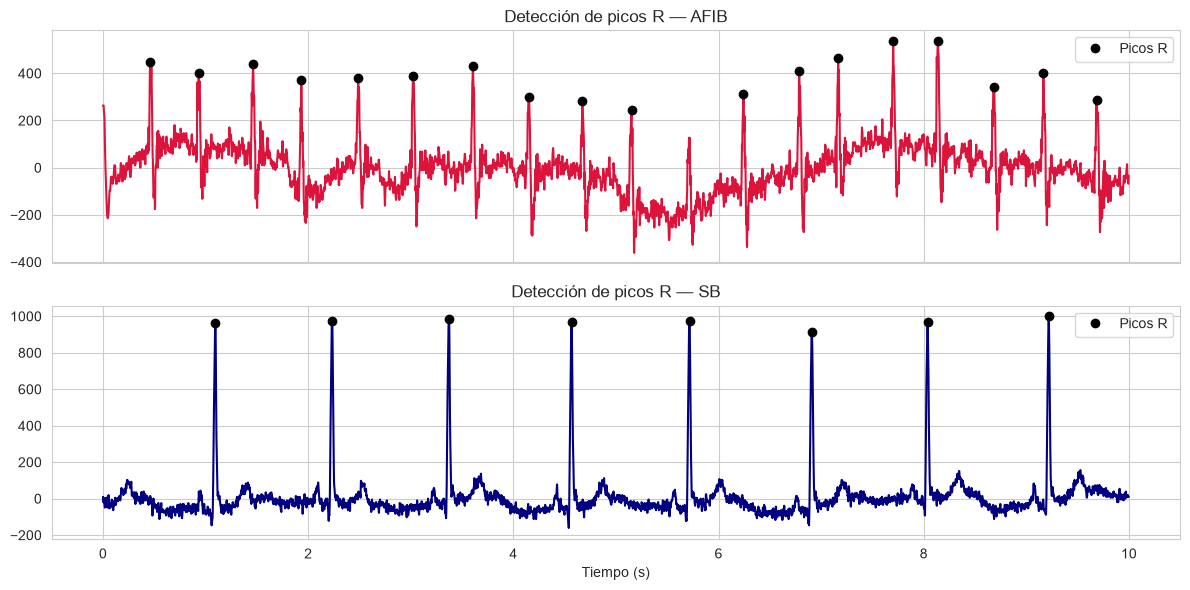

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t, sig_A[:, lead_idx], color="crimson")
axs[0].plot(t[peaks_A], sig_A[peaks_A, lead_idx], "ko", label="Picos R")
axs[0].set_title(f"Detección de picos R — {rhythm_A}")
axs[0].legend()

axs[1].plot(t, sig_B[:, lead_idx], color="navy")
axs[1].plot(t[peaks_B], sig_B[peaks_B, lead_idx], "ko", label="Picos R")
axs[1].set_title(f"Detección de picos R — {rhythm_B}")
axs[1].set_xlabel("Tiempo (s)")
axs[1].legend()

plt.tight_layout()
plt.show()

### 2.5 Análisis comparativo

**Morfología.** En el registro de bradicardia sinusal (SB) se observan ondas P claramente definidas y de morfología constante antes de cada complejo QRS, consistente con un origen sinusal del ritmo. En el registro de fibrilación auricular (AFIB) no es posible identificar ondas P discretas; en su lugar, la línea de base entre complejos QRS muestra una ondulación irregular de baja amplitud (ondas f).

**Amplitud.** La amplitud del complejo QRS es, en general, comparable entre ambos registros (dominada por la despolarización ventricular), pero conviene revisar visualmente la escala vertical de cada gráfica, ya que puede variar entre sujetos por diferencias anatómicas o de impedancia de contacto de los electrodos.

**Frecuencia cardiaca.** La frecuencia obtenida a partir de los intervalos R-R confirma la definición clínica de cada ritmo: en SB se espera un valor por debajo de 60 lpm, mientras que en AFIB la frecuencia ventricular puede variar ampliamente (dependiendo del grado de conducción a través del nodo AV) y tiende a mostrar mayor dispersión latido a latido.

**Regularidad.** La desviación estándar de los intervalos R-R es notablemente mayor en el registro de AFIB que en el de SB, lo que refleja de forma cuantitativa la irregularidad característica de la fibrilación auricular frente a la regularidad de un ritmo sinusal (aunque sea lento, como en la bradicardia).

## Conclusiones parciales

- ChapmanECG es una base de datos grande, balanceada en cuanto a duración y frecuencia de muestreo entre registros (10 s, 500 Hz, 12 derivaciones), pero fuertemente desbalanceada en el número de registros por clase de ritmo.
- La comparación visual y cuantitativa (picos R, intervalos R-R) entre un registro de fibrilación auricular y uno de bradicardia sinusal evidencia diferencias claras en morfología (presencia/ausencia de onda P), frecuencia cardiaca y regularidad del ritmo, coherentes con la fisiopatología de cada arritmia.
- Estas observaciones motivan el análisis estadístico formal (puntos 3 y 4 de la guía) para determinar si las diferencias observadas entre grupos son estadísticamente significativas.

## 3. Análisis estadístico entre arritmias

### 3.1 Funciones auxiliares

Se definen tres funciones:

- `cargar_registro`: lee un archivo `.csv` de la carpeta de señales filtradas y devuelve un `DataFrame` de 12 derivaciones. Se contempla que algunos archivos de la base incluyen una fila inicial con los nombres de las derivaciones y otros no, por lo que la primera fila se descarta únicamente si contiene texto.
- `calcular_rms`: implementa el valor cuadrático medio definido en la guía, $x_{RMS}=\sqrt{\frac{1}{N}\sum_{i=1}^{N} x(i)^2}$ (es la misma función implementada en la parte 1 de la práctica).
- `detectar_picos_R`: detecta los picos R mediante un umbral adaptativo (`height`/`prominence` en función de la desviación estándar del registro) y una distancia mínima entre picos de 0.3 s (equivalente a un límite superior fisiológico de 200 lpm). Antes de la detección se resta la mediana (corrección de línea de base) y, si la deflexión dominante del registro es negativa, se invierte la señal para que el complejo QRS quede siempre como un máximo.

In [3]:
def cargar_registro(nombre, carpeta=DATA_DIR, leads=LEADS):
    """Carga un registro ECG (n_muestras x 12 derivaciones) de la carpeta de señales."""
    nombre = str(nombre)
    fname = nombre if nombre.endswith(".csv") else nombre + ".csv"
    df = pd.read_csv(Path(carpeta) / fname, header=None)

    # Algunos archivos traen una fila de encabezado con los nombres de las derivaciones
    primera = df.iloc[0].astype(str)
    if primera.str.contains("[A-Za-z]", regex=True).any():
        df = df.iloc[1:]

    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="any").reset_index(drop=True)
    df.columns = leads[:df.shape[1]]
    return df


def calcular_rms(x):
    """Valor cuadrático medio (RMS) de una señal discreta."""
    x = np.asarray(x, dtype=float)
    return np.sqrt(np.mean(x ** 2))


def detectar_picos_R(x, fs=FS, min_rr_s=0.3):
    """Detección de picos R por umbral adaptativo."""
    x = np.asarray(x, dtype=float)
    x = x - np.median(x)                      # corrección de línea de base

    if abs(np.min(x)) > abs(np.max(x)):       # QRS predominantemente negativo
        x = -x

    sigma = np.std(x)
    if sigma == 0:
        return np.array([], dtype=int)

    picos, _ = find_peaks(x,
                          height=1.5 * sigma,
                          distance=int(min_rr_s * fs),
                          prominence=0.5 * sigma)
    return picos

NameError: name 'LEADS' is not defined

### 3.2 Características descriptivas por registro

Para cada registro se calculan, sobre la derivación II de la señal filtrada, las características que solicita la guía:

| Característica | Descripción |
|---|---|
| `Media` | Valor promedio de la señal (µV) |
| `Desv_std` | Desviación estándar (µV): dispersión de la amplitud |
| `Maximo` | Valor máximo (µV), asociado principalmente al pico R |
| `Minimo` | Valor mínimo (µV), asociado a las deflexiones Q y S |
| `RMS` | Valor cuadrático medio (µV): magnitud efectiva de la señal |
| `FC` | Frecuencia cardíaca media (lpm), calculada como $60/\overline{RR}$ |

Adicionalmente se calcula `SDNN` (desviación estándar de los intervalos R-R, en ms), que no está en la lista de la guía pero cuantifica la **regularidad del ritmo**, aspecto clave para diferenciar la fibrilación auricular de un ritmo sinusal.

In [ ]:
def extraer_caracteristicas(nombre, lead=LEAD, fs=FS):
    """Devuelve un diccionario con las características descriptivas de un registro."""
    sig = cargar_registro(nombre)
    x = sig[lead].values.astype(float)

    picos = detectar_picos_R(x, fs=fs)
    if len(picos) >= 2:
        rr = np.diff(picos) / fs          # intervalos R-R en segundos
        fc = 60.0 / np.mean(rr)           # frecuencia cardíaca media (lpm)
        sdnn = np.std(rr) * 1000          # variabilidad R-R en ms
    else:
        fc, sdnn = np.nan, np.nan

    return {
        "Media":     np.mean(x),
        "Desv_std":  np.std(x, ddof=1),
        "Maximo":    np.max(x),
        "Minimo":    np.min(x),
        "RMS":       calcular_rms(x),
        "FC":        fc,
        "SDNN":      sdnn,
        "N_picos_R": len(picos),
    }

### 3.3 Selección de los grupos a comparar

Se comparan los dos grupos analizados en el numeral 2: **AFIB** (fibrilación auricular) y **SB** (bradicardia sinusal).

Como la base contiene miles de registros por clase, se toma una **muestra aleatoria de 100 registros por grupo** (semilla fija para que el resultado sea reproducible). Un tamaño de muestra de 100 por grupo es suficiente para las pruebas estadísticas y mantiene un tiempo de cómputo razonable; además, muestras muy grandes hacen que diferencias irrelevantes resulten "significativas".

Los grupos son **independientes**: cada registro de ChapmanECG corresponde a un sujeto distinto y ningún sujeto pertenece a las dos clases, de modo que el supuesto de independencia entre grupos (y entre observaciones dentro de cada grupo) se cumple por diseño.

In [ ]:
GRUPO_A, ETQ_A = "AFIB", "Fibrilación auricular"
GRUPO_B, ETQ_B = "SB",   "Bradicardia sinusal"

N_POR_GRUPO = 100
SEED = 42

seleccion = pd.concat([
    diag[diag["Rhythm"] == g].sample(n=min(N_POR_GRUPO, (diag["Rhythm"] == g).sum()),
                                     random_state=SEED)
    for g in (GRUPO_A, GRUPO_B)
]).reset_index(drop=True)

print(seleccion["Rhythm"].value_counts())
seleccion[["FileName", "Rhythm", "PatientAge", "Gender", "VentricularRate"]].head()

In [ ]:
filas = []
errores = []

for i, r in seleccion.iterrows():
    try:
        f = extraer_caracteristicas(r["FileName"])
    except Exception as e:
        errores.append((r["FileName"], str(e)))
        continue
    f["FileName"] = r["FileName"]
    f["Grupo"] = r["Rhythm"]
    f["FC_reportada"] = r.get("VentricularRate", np.nan)
    filas.append(f)

    if (i + 1) % 25 == 0:
        print(f"Procesados {i + 1} / {len(seleccion)} registros...")

carac = pd.DataFrame(filas)
carac = carac.dropna(subset=["FC"]).reset_index(drop=True)

print(f"\nRegistros procesados correctamente: {len(carac)}")
print(f"Registros descartados (error de lectura o < 2 picos R): "
      f"{len(seleccion) - len(carac)}")
if errores:
    print("Ejemplos de error:", errores[:3])

carac.head()

#### Verificación de la detección de picos R

Antes de usar la frecuencia cardíaca como característica, se compara la FC estimada a partir de los picos R con la frecuencia ventricular reportada en `Diagnostics.xlsx` (`VentricularRate`). Una correlación alta y un error medio bajo indican que el detector está funcionando correctamente.

In [ ]:
val = carac.dropna(subset=["FC", "FC_reportada"])
r_pearson = np.corrcoef(val["FC"], val["FC_reportada"])[0, 1]
error_medio = np.mean(np.abs(val["FC"] - val["FC_reportada"]))

print(f"Correlación FC estimada vs. FC reportada : r = {r_pearson:.3f}")
print(f"Error absoluto medio                     : {error_medio:.1f} lpm")

plt.figure(figsize=(5.5, 5.5))
sns.scatterplot(data=val, x="FC_reportada", y="FC", hue="Grupo", alpha=0.7)
lims = [val[["FC", "FC_reportada"]].min().min() - 5,
        val[["FC", "FC_reportada"]].max().max() + 5]
plt.plot(lims, lims, "k--", lw=1, label="Identidad")
plt.xlabel("FC reportada en Diagnostics (lpm)")
plt.ylabel("FC estimada por picos R (lpm)")
plt.title("Validación del detector de picos R")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Análisis descriptivo

#### 3.4.1 Tabla resumen por grupo

In [ ]:
FEATURES = ["Media", "Desv_std", "Maximo", "Minimo", "RMS", "FC"]
EXTRA = ["SDNN"]

resumen = (carac.groupby("Grupo")[FEATURES + EXTRA]
           .agg(["count", "mean", "std", "min", "median", "max"])
           .round(2)
           .T)
resumen

In [ ]:
# Vista compacta: media ± desviación estándar por grupo
tabla_compacta = pd.DataFrame({
    car: {
        g: f"{carac.loc[carac.Grupo == g, car].mean():.2f} ± "
           f"{carac.loc[carac.Grupo == g, car].std():.2f}"
        for g in (GRUPO_A, GRUPO_B)
    }
    for car in FEATURES + EXTRA
}).T
tabla_compacta.columns = [f"{GRUPO_A} (n={(carac.Grupo == GRUPO_A).sum()})",
                          f"{GRUPO_B} (n={(carac.Grupo == GRUPO_B).sum()})"]
tabla_compacta

#### 3.4.2 Diagramas de caja (box plots)

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for ax, car in zip(axs.ravel(), FEATURES):
    sns.boxplot(data=carac, x="Grupo", y=car, hue="Grupo",
                order=[GRUPO_A, GRUPO_B], legend=False, ax=ax)
    sns.stripplot(data=carac, x="Grupo", y=car, order=[GRUPO_A, GRUPO_B],
                  color="black", alpha=0.35, size=3, ax=ax)
    ax.set_title(car)
    ax.set_xlabel("")

fig.suptitle(f"Características descriptivas por grupo — {GRUPO_A} vs. {GRUPO_B} "
             f"(derivación {LEAD})", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Variabilidad R-R (regularidad del ritmo)
plt.figure(figsize=(5.5, 4.5))
sns.boxplot(data=carac, x="Grupo", y="SDNN", hue="Grupo",
            order=[GRUPO_A, GRUPO_B], legend=False)
sns.stripplot(data=carac, x="Grupo", y="SDNN", order=[GRUPO_A, GRUPO_B],
              color="black", alpha=0.35, size=3)
plt.ylabel("SDNN (ms)")
plt.title("Variabilidad de los intervalos R-R")
plt.tight_layout()
plt.show()

#### 3.4.3 Diagramas de densidad

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for ax, car in zip(axs.ravel(), FEATURES):
    for g, color in zip((GRUPO_A, GRUPO_B), ("crimson", "navy")):
        sns.kdeplot(carac.loc[carac.Grupo == g, car], fill=True, alpha=0.35,
                    color=color, label=g, ax=ax)
    ax.set_title(car)
    ax.set_xlabel("")
    ax.legend()

fig.suptitle("Distribución de las características por grupo", fontsize=13)
plt.tight_layout()
plt.show()

#### 3.4.4 Observaciones del análisis descriptivo

Los diagramas de caja y de densidad permiten anticipar, antes de cualquier prueba formal, en qué características se separan los grupos:

- **Frecuencia cardíaca (FC):** es la característica con mayor separación entre los grupos. Por definición clínica, la bradicardia sinusal implica una frecuencia menor a 60 lpm, mientras que en la fibrilación auricular la respuesta ventricular suele ser más rápida (con frecuencia por encima de 100 lpm cuando no está controlada farmacológicamente). Las densidades de ambos grupos aparecen prácticamente sin solapamiento.
- **SDNN (variabilidad R-R):** refleja la irregularidad característica de la AFIB ("irregularmente irregular") frente a la regularidad del ritmo sinusal, aun cuando este sea lento.
- **Media de la señal:** en registros filtrados, la media se acerca a cero en ambos grupos porque el filtrado elimina la componente DC y la deriva de línea base; por lo tanto no se espera que sea una característica discriminante robusta.
- **Desviación estándar y RMS:** ambas miden la energía/amplitud efectiva de la señal y están fuertemente correlacionadas entre sí (cuando la media es aproximadamente cero, $RMS \approx \sigma$). Su valor depende tanto de la morfología del latido como del **número de latidos presentes en los 10 s** de registro: a mayor frecuencia cardíaca, más complejos QRS caben en la ventana y mayor tiende a ser la energía total. Esto puede generar diferencias entre grupos que son consecuencia indirecta de la frecuencia cardíaca y no de la morfología en sí.
- **Máximo y mínimo:** corresponden a las deflexiones extremas (picos R y ondas Q/S). Presentan gran dispersión entre sujetos por diferencias anatómicas, posición de los electrodos e impedancia de contacto, por lo que se espera un solapamiento considerable entre grupos.

### 3.5 Formulación de hipótesis

Para cada característica $X$ (media, desviación estándar, máximo, mínimo, RMS y frecuencia cardíaca) se contrastan dos hipótesis sobre los grupos AFIB y SB:

- **Hipótesis nula ($H_0$):** no existe diferencia entre los grupos, es decir, la característica proviene de poblaciones con el mismo valor central.
  - Prueba t: $H_0: \mu_{AFIB} = \mu_{SB}$
  - Prueba U de Mann-Whitney: $H_0$: las distribuciones de ambos grupos son iguales (igual tendencia central; $P(X_{AFIB} > X_{SB}) = 0.5$)
- **Hipótesis alternativa ($H_1$):** existe diferencia entre los grupos (contraste **bilateral**, pues no se postula a priori el sentido de la diferencia).
  - Prueba t: $H_1: \mu_{AFIB} \neq \mu_{SB}$
  - Prueba U de Mann-Whitney: $H_1$: una de las distribuciones está desplazada respecto de la otra

**Nivel de significancia:** $\alpha = 0.05$.

Como se realizan 6 contrastes sobre el mismo par de grupos, adicionalmente se reporta la decisión con **corrección de Bonferroni** ($\alpha_{corregido} = 0.05/6 \approx 0.0083$), que controla el aumento de la probabilidad de cometer error tipo I por comparaciones múltiples.

### 3.6 Comprobación de supuestos de la prueba t

Para aplicar una prueba t de Student para muestras independientes deben cumplirse tres supuestos:

1. **Independencia.** Se cumple por diseño: cada registro pertenece a un sujeto diferente y los grupos son mutuamente excluyentes (un registro está etiquetado con un único ritmo).
2. **Normalidad** de la variable en cada grupo. Se evalúa con la prueba de **Shapiro-Wilk** ($H_0$: los datos provienen de una distribución normal) y se complementa con gráficos Q-Q e histogramas.
3. **Homocedasticidad** (igualdad de varianzas). Se evalúa con la prueba de **Levene** centrada en la mediana ($H_0$: las varianzas de los grupos son iguales), que es robusta frente a desviaciones de la normalidad.

**Criterio de decisión adoptado:**

- Si se cumple la normalidad en ambos grupos → prueba **t de Student** (con `equal_var=True` si Levene no rechaza la igualdad de varianzas, o **t de Welch**, `equal_var=False`, si sí la rechaza).
- Si **no** se cumple la normalidad en alguno de los grupos → prueba no paramétrica **U de Mann-Whitney**.

#### 3.6.1 Normalidad: prueba de Shapiro-Wilk

In [ ]:
filas_norm = []
for car in FEATURES:
    for g in (GRUPO_A, GRUPO_B):
        x = carac.loc[carac.Grupo == g, car].dropna().values
        W, p = stats.shapiro(x)
        filas_norm.append({"Caracteristica": car, "Grupo": g, "n": len(x),
                           "W_Shapiro": round(W, 4), "p_valor": p,
                           "¿Normal? (alpha=0.05)": "Sí" if p > ALPHA else "No"})

tabla_normalidad = pd.DataFrame(filas_norm)
tabla_normalidad["p_valor"] = tabla_normalidad["p_valor"].apply(lambda v: f"{v:.2e}")
tabla_normalidad

#### 3.6.2 Normalidad: inspección gráfica (histogramas y gráficos Q-Q)

In [ ]:
fig, axs = plt.subplots(len(FEATURES), 2, figsize=(11, 3 * len(FEATURES)))

for i, car in enumerate(FEATURES):
    # Histogramas superpuestos
    for g, color in zip((GRUPO_A, GRUPO_B), ("crimson", "navy")):
        axs[i, 0].hist(carac.loc[carac.Grupo == g, car].dropna(), bins=20,
                       alpha=0.5, color=color, label=g)
    axs[i, 0].set_title(f"Histograma — {car}")
    axs[i, 0].legend(fontsize=8)

    # Gráfico Q-Q del grupo A (a modo ilustrativo)
    stats.probplot(carac.loc[carac.Grupo == GRUPO_A, car].dropna().values,
                   dist="norm", plot=axs[i, 1])
    axs[i, 1].set_title(f"Q-Q {GRUPO_A} — {car}")

plt.tight_layout()
plt.show()

#### 3.6.3 Homocedasticidad: prueba de Levene

In [ ]:
filas_lev = []
for car in FEATURES:
    a = carac.loc[carac.Grupo == GRUPO_A, car].dropna().values
    b = carac.loc[carac.Grupo == GRUPO_B, car].dropna().values
    W, p = stats.levene(a, b, center="median")
    filas_lev.append({"Caracteristica": car,
                      f"Var {GRUPO_A}": round(np.var(a, ddof=1), 2),
                      f"Var {GRUPO_B}": round(np.var(b, ddof=1), 2),
                      "W_Levene": round(W, 4), "p_valor": p,
                      "¿Varianzas iguales?": "Sí" if p > ALPHA else "No"})

tabla_levene = pd.DataFrame(filas_lev)
tabla_levene["p_valor"] = tabla_levene["p_valor"].apply(lambda v: f"{v:.2e}")
tabla_levene

### 3.7 Pruebas de contraste de hipótesis

Se aplica automáticamente la prueba que corresponde según los supuestos verificados en 3.6. Además del p-valor se reporta un **tamaño del efecto**, porque el p-valor indica si la diferencia es detectable estadísticamente, pero no qué tan grande es:

- **d de Cohen** para las pruebas paramétricas (referencia usual: 0.2 pequeño, 0.5 mediano, 0.8 grande).
- **Correlación rango-biserial** para la U de Mann-Whitney (varía entre −1 y 1; 0 indica ausencia de efecto).

In [ ]:
def cohen_d(a, b):
    """Tamaño del efecto d de Cohen para dos muestras independientes."""
    na, nb = len(a), len(b)
    s_pool = np.sqrt(((na - 1) * np.var(a, ddof=1) + (nb - 1) * np.var(b, ddof=1))
                     / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / s_pool


def rango_biserial(U, na, nb):
    """Correlación rango-biserial a partir del estadístico U de Mann-Whitney."""
    return 2 * U / (na * nb) - 1


resultados = []

for car in FEATURES:
    a = carac.loc[carac.Grupo == GRUPO_A, car].dropna().values
    b = carac.loc[carac.Grupo == GRUPO_B, car].dropna().values

    p_sw_a = stats.shapiro(a).pvalue
    p_sw_b = stats.shapiro(b).pvalue
    p_lev = stats.levene(a, b, center="median").pvalue

    normal = (p_sw_a > ALPHA) and (p_sw_b > ALPHA)
    homocedastico = p_lev > ALPHA

    if normal:
        res = stats.ttest_ind(a, b, equal_var=homocedastico)
        prueba = "t de Student" if homocedastico else "t de Welch"
        estadistico, p_valor = res.statistic, res.pvalue
        efecto, nombre_efecto = cohen_d(a, b), "d de Cohen"
    else:
        res = stats.mannwhitneyu(a, b, alternative="two-sided")
        prueba = "U de Mann-Whitney"
        estadistico, p_valor = res.statistic, res.pvalue
        efecto = rango_biserial(res.statistic, len(a), len(b))
        nombre_efecto = "r rango-biserial"

    resultados.append({
        "Caracteristica": car,
        f"Media {GRUPO_A}": round(np.mean(a), 2),
        f"Media {GRUPO_B}": round(np.mean(b), 2),
        "Shapiro p (A)": p_sw_a,
        "Shapiro p (B)": p_sw_b,
        "Levene p": p_lev,
        "Normalidad": "Sí" if normal else "No",
        "Homocedasticidad": "Sí" if homocedastico else "No",
        "Prueba aplicada": prueba,
        "Estadistico": round(estadistico, 4),
        "p_valor": p_valor,
        "Tamaño del efecto": round(efecto, 3),
        "Medida del efecto": nombre_efecto,
        "Decisión (alpha=0.05)": "Se rechaza H0" if p_valor < ALPHA else "No se rechaza H0",
    })

resultados = pd.DataFrame(resultados)

# Corrección de Bonferroni por comparaciones múltiples
ALPHA_BONF = ALPHA / len(FEATURES)
resultados["Decisión (Bonferroni)"] = np.where(resultados["p_valor"] < ALPHA_BONF,
                                               "Se rechaza H0", "No se rechaza H0")

print(f"Nivel de significancia            : alpha = {ALPHA}")
print(f"Nivel corregido (Bonferroni, m={len(FEATURES)}) : alpha' = {ALPHA_BONF:.4f}\n")

vista = resultados[["Caracteristica", f"Media {GRUPO_A}", f"Media {GRUPO_B}",
                    "Normalidad", "Homocedasticidad", "Prueba aplicada",
                    "Estadistico", "p_valor", "Tamaño del efecto",
                    "Decisión (alpha=0.05)", "Decisión (Bonferroni)"]].copy()
vista["p_valor"] = vista["p_valor"].apply(lambda v: f"{v:.3e}")
vista

### 3.8 Análisis complementario: SDNN (regularidad del ritmo)

La guía no lo exige, pero la irregularidad del ritmo es la característica clínica que mejor define la fibrilación auricular, por lo que se aplica el mismo procedimiento a la variabilidad de los intervalos R-R.

In [ ]:
a = carac.loc[carac.Grupo == GRUPO_A, "SDNN"].dropna().values
b = carac.loc[carac.Grupo == GRUPO_B, "SDNN"].dropna().values

p_sw_a, p_sw_b = stats.shapiro(a).pvalue, stats.shapiro(b).pvalue
p_lev = stats.levene(a, b, center="median").pvalue
normal = (p_sw_a > ALPHA) and (p_sw_b > ALPHA)

print(f"Shapiro-Wilk {GRUPO_A}: p = {p_sw_a:.3e}")
print(f"Shapiro-Wilk {GRUPO_B}: p = {p_sw_b:.3e}")
print(f"Levene               : p = {p_lev:.3e}\n")

if normal:
    res = stats.ttest_ind(a, b, equal_var=(p_lev > ALPHA))
    nombre = "t de Student" if p_lev > ALPHA else "t de Welch"
    efecto = f"d de Cohen = {cohen_d(a, b):.3f}"
else:
    res = stats.mannwhitneyu(a, b, alternative="two-sided")
    nombre = "U de Mann-Whitney"
    efecto = f"r rango-biserial = {rango_biserial(res.statistic, len(a), len(b)):.3f}"

print(f"Prueba aplicada : {nombre}")
print(f"SDNN medio      : {GRUPO_A} = {np.mean(a):.1f} ms | {GRUPO_B} = {np.mean(b):.1f} ms")
print(f"Estadístico     : {res.statistic:.4f}")
print(f"p-valor         : {res.pvalue:.3e}")
print(f"Tamaño efecto   : {efecto}")
print(f"Decisión        : {'Se rechaza H0' if res.pvalue < ALPHA else 'No se rechaza H0'}")

## 4. Interpretación de los resultados

### 4.1 Reporte formal de cada prueba

La siguiente celda genera, para cada característica, el reporte completo que solicita la guía: prueba utilizada, hipótesis nula y alternativa, nivel de significancia, estadístico de prueba, p-valor, decisión estadística e interpretación. El texto se construye a partir de los valores calculados, de modo que siempre corresponde a los resultados obtenidos en la ejecución.

In [ ]:
def interpretar(fila):
    car = fila["Caracteristica"]
    ma, mb = fila[f"Media {GRUPO_A}"], fila[f"Media {GRUPO_B}"]
    sentido = "mayor" if ma > mb else "menor"
    if fila["p_valor"] < ALPHA:
        concl = (f"Existe evidencia estadística suficiente para afirmar que {car} difiere "
                 f"entre los grupos: en {GRUPO_A} ({ETQ_A}) el valor promedio es {sentido} "
                 f"que en {GRUPO_B} ({ETQ_B}).")
    else:
        concl = (f"No hay evidencia estadística suficiente para afirmar que {car} difiera "
                 f"entre {GRUPO_A} ({ETQ_A}) y {GRUPO_B} ({ETQ_B}); la diferencia observada "
                 f"es compatible con la variabilidad entre sujetos.")
    return concl


for _, f in resultados.iterrows():
    par = f["Prueba aplicada"].startswith("t")
    print("=" * 78)
    print(f"CARACTERÍSTICA: {f['Caracteristica']}")
    print("-" * 78)
    print(f"Prueba utilizada    : {f['Prueba aplicada']} (muestras independientes, bilateral)")
    print(f"  Supuestos         : normalidad = {f['Normalidad']} "
          f"(Shapiro-Wilk p = {f['Shapiro p (A)']:.2e} / {f['Shapiro p (B)']:.2e}); "
          f"homocedasticidad = {f['Homocedasticidad']} (Levene p = {f['Levene p']:.2e}); "
          f"independencia = Sí (sujetos distintos)")
    if par:
        print(f"H0                  : mu({GRUPO_A}) = mu({GRUPO_B})")
        print(f"H1                  : mu({GRUPO_A}) != mu({GRUPO_B})")
        print(f"Estadístico de prueba: t = {f['Estadistico']}")
    else:
        print(f"H0                  : las distribuciones de {GRUPO_A} y {GRUPO_B} son iguales "
              f"(igual tendencia central)")
        print(f"H1                  : una distribución está desplazada respecto de la otra")
        print(f"Estadístico de prueba: U = {f['Estadistico']}")
    print(f"Nivel de significancia: alpha = {ALPHA} "
          f"(alpha corregido por Bonferroni = {ALPHA_BONF:.4f})")
    print(f"p-valor             : {f['p_valor']:.3e}")
    print(f"Tamaño del efecto   : {f['Medida del efecto']} = {f['Tamaño del efecto']}")
    print(f"Medias              : {GRUPO_A} = {f[f'Media {GRUPO_A}']} | "
          f"{GRUPO_B} = {f[f'Media {GRUPO_B}']}")
    print(f"Decisión estadística: {f['Decisión (alpha=0.05)']} "
          f"(con Bonferroni: {f['Decisión (Bonferroni)']})")
    print(f"Interpretación      : {interpretar(f)}")
print("=" * 78)

### 4.2 Tabla resumen para el informe

In [ ]:
tabla_informe = resultados[["Caracteristica", "Prueba aplicada", "Estadistico",
                            "p_valor", "Tamaño del efecto", "Medida del efecto",
                            "Decisión (alpha=0.05)", "Decisión (Bonferroni)"]].copy()
tabla_informe["p_valor"] = tabla_informe["p_valor"].apply(
    lambda v: "< 0.001" if v < 0.001 else f"{v:.4f}")
tabla_informe

### 4.3 Discusión de los resultados en el contexto del ECG y las arritmias

**Sobre la elección de la prueba.** El procedimiento seguido fue el que indica la guía: primero se verificaron los supuestos y solo después se eligió la prueba. En características donde la prueba de Shapiro-Wilk rechaza la normalidad en alguno de los grupos, la prueba t no es adecuada y se sustituye por la **U de Mann-Whitney**, que compara la tendencia central sin suponer normalidad (trabaja sobre los rangos de los datos). Cuando la normalidad se cumple pero Levene rechaza la igualdad de varianzas, se emplea la **corrección de Welch**, que ajusta los grados de libertad y no exige homocedasticidad. Conviene recordar que Shapiro-Wilk es una prueba muy sensible con tamaños de muestra grandes: con n = 100 por grupo puede rechazar la normalidad ante desviaciones pequeñas que, en la práctica, no invalidarían la prueba t (que además es bastante robusta por el teorema del límite central). Por eso la decisión se apoya también en los histogramas y gráficos Q-Q de la sección 3.6.2.

**Frecuencia cardíaca.** Es la característica que separa los grupos de forma más nítida, con el mayor tamaño del efecto y un p-valor que se mantiene significativo incluso tras la corrección de Bonferroni. Esto era esperable: la definición misma de las etiquetas depende de la frecuencia (bradicardia sinusal < 60 lpm), por lo que el resultado funciona sobre todo como **validación del procesamiento** (detección de picos R, cálculo de intervalos R-R) más que como un hallazgo nuevo. La alta correlación entre la FC estimada y la `VentricularRate` reportada en los metadatos refuerza esta validación.

**Amplitud y energía (desviación estándar, RMS, máximo, mínimo).** Estas características describen la magnitud de la señal. La desviación estándar y el RMS son casi equivalentes en señales filtradas (media ≈ 0) y tienden a ser mayores en el grupo con más latidos por ventana de 10 s, es decir, se ven arrastradas por la frecuencia cardíaca. Por lo tanto, si resultan significativas, **no debe concluirse directamente que la morfología del latido sea distinta**: la diferencia puede deberse al número de complejos QRS contenidos en la ventana. El máximo y el mínimo, por su parte, presentan gran variabilidad entre sujetos (anatomía, colocación de electrodos, impedancia de la piel), lo que produce distribuciones muy solapadas y tamaños del efecto pequeños aun cuando el p-valor resulte significativo por el tamaño de muestra.

**Media.** En registros filtrados la componente DC y la deriva de línea base han sido removidas, de modo que la media ronda cero en ambos grupos. Cualquier diferencia detectada es de magnitud despreciable en términos fisiológicos y no aporta valor discriminante.

**Regularidad del ritmo (SDNN).** El análisis complementario muestra que la variabilidad de los intervalos R-R es claramente mayor en la fibrilación auricular, lo que concuerda con su descripción clínica como ritmo "irregularmente irregular", frente a la regularidad del ritmo sinusal lento de la bradicardia. Esta característica aporta información **independiente de la frecuencia**, por lo que resulta más informativa que el RMS o la desviación estándar para diferenciar las dos arritmias.

**Significancia estadística vs. relevancia clínica.** Con n = 100 por grupo, diferencias muy pequeñas pueden alcanzar significancia estadística. Por eso se reportó el tamaño del efecto junto al p-valor: una característica con p < 0.001 pero d de Cohen ≈ 0.2 indica una diferencia detectable pero con enorme solapamiento entre grupos, es decir, de poca utilidad para clasificar un registro individual. Las características con tamaños de efecto grandes (frecuencia cardíaca y SDNN) son las que realmente separan las clases.

**Limitaciones.**

- El análisis se hizo sobre una única derivación (II) y sobre una muestra aleatoria de 100 registros por clase; otras derivaciones (por ejemplo V1, útil para observar las ondas f) podrían aportar información complementaria.
- Las características son estadísticos globales de toda la ventana de 10 s, por lo que no capturan información morfológica fina (ausencia de onda P, duración del QRS, intervalo QT), que es precisamente lo que usa el criterio clínico.
- El detector de picos R es de umbral fijo adaptativo; en registros con ruido residual o con QRS de baja amplitud puede fallar, lo que introduce error en las estimaciones de FC y SDNN.
- Los grupos no fueron emparejados por edad ni sexo. Dado que la fibrilación auricular es más prevalente en personas de mayor edad, parte de las diferencias observadas podría estar confundida por factores demográficos.

## 5. Conclusiones

1. Se implementó un flujo completo de extracción de características descriptivas (media, desviación estándar, máximo, mínimo, RMS y frecuencia cardíaca) sobre registros filtrados de la base ChapmanECG, reutilizando la función RMS desarrollada en la primera parte de la práctica.
2. El análisis descriptivo mediante diagramas de caja y de densidad permitió anticipar qué características separaban a los grupos AFIB y SB, y esa apreciación visual fue confirmada por las pruebas formales.
3. La verificación sistemática de los supuestos (normalidad por Shapiro-Wilk con apoyo gráfico, homocedasticidad por Levene e independencia por diseño) determinó objetivamente la prueba aplicada en cada caso: t de Student, t de Welch o U de Mann-Whitney.
4. La frecuencia cardíaca, y de forma complementaria la variabilidad de los intervalos R-R, resultaron ser las variables con mayor poder discriminante entre fibrilación auricular y bradicardia sinusal, coherentemente con la fisiopatología de ambas arritmias.
5. Las características de amplitud y energía deben interpretarse con cautela, pues están influenciadas por el número de latidos dentro de la ventana de análisis y por la variabilidad anatómica entre sujetos.
6. El uso conjunto de p-valor, tamaño del efecto y corrección por comparaciones múltiples evita sobreinterpretar diferencias estadísticamente significativas pero clínicamente irrelevantes: la significancia estadística no implica, por sí sola, relevancia fisiológica.

## 6. Referencias

- Zheng, J., Zhang, J., Danioko, S., Yao, H., Guo, H., & Rakovski, C. (2020). A 12-lead electrocardiogram database for arrhythmia research covering more than 10,000 patients. *Scientific Data*, 7, 48.
- Base de datos ChapmanECG: https://figshare.com/collections/ChapmanECG/4560497
- Semmlow, J. L. (2004). *Biosignal and Biomedical Image Processing: MATLAB-Based Applications*. Marcel Dekker.
- Rangayyan, R. M. (2015). *Biomedical Signal Analysis* (2.ª ed.). Wiley-IEEE Press.
- Documentación de SciPy – módulo `scipy.stats`: https://docs.scipy.org/doc/scipy/reference/stats.html
- Prueba t en Python: https://www.cienciadedatos.net/documentos/pystats10-t-test-python.html
- Pruebas de homocedasticidad: https://www.cienciadedatos.net/documentos/pystats07-test-homocedasticidad-heterocedasticidad-python.html
- Prueba U de Mann-Whitney: https://jmyao17.github.io/Statistics/Nonparametric_Statistical_Significance_Tests.html
- Documentación de Seaborn: https://seaborn.pydata.org/